In [1]:
%load_ext autoreload
%autoreload 2

# 01 — Exploration des données Hi-UCD

Objectif (Phase 0) : maîtriser le masque 3 canaux, visualiser les classes,
calculer la distribution, repérer le déséquilibre.

Ce notebook sert à **comprendre**. Tout ce qui sera rejoué (dataloader,
modèle…) ira dans `src/`, pas ici.

In [2]:
# Permet d'importer src/ depuis le notebook
import sys, os
sys.path.append(os.path.abspath('..'))

from src.utils.device import get_device
device = get_device()   # doit afficher 'MPS actif' sur ton Mac

[device] MPS actif -> GPU Apple Silicon (local)


In [3]:
from pathlib import Path

ROOT = Path("/Volumes/SSD_VICO/hi-ucd-complete")  # adapte si besoin
assert ROOT.exists(), f"Chemin introuvable — le SSD est-il branché ? {ROOT}"

# Liste les dossiers jusqu'à 2 niveaux de profondeur
for p in sorted(ROOT.rglob("*")):
    depth = len(p.relative_to(ROOT).parts)
    if p.is_dir() and depth <= 2:
        print("  " * (depth - 1) + "📁 " + p.name)

📁 test
  📁 image
📁 train
  📁 image
  📁 mask
📁 val
  📁 image
  📁 mask


In [4]:
# Tous les PNG, triés par dossier parent pour voir la structure
from collections import Counter

pngs = list(ROOT.rglob("*.png"))
print(f"Total PNG : {len(pngs)}\n")

# Combien de PNG par dossier parent ?
par_dossier = Counter(p.parent.relative_to(ROOT).as_posix() for p in pngs)
for dossier, n in sorted(par_dossier.items()):
    print(f"{n:>7} fichiers  dans  {dossier}/")

Total PNG : 100803

  21600 fichiers  dans  test/image/2018/
  21600 fichiers  dans  test/image/2019/
  12001 fichiers  dans  train/image/2018/
  12001 fichiers  dans  train/image/2019/
  12001 fichiers  dans  train/mask/2018_2019/
   7200 fichiers  dans  val/image/2018/
   7200 fichiers  dans  val/image/2019/
   7200 fichiers  dans  val/mask/2018_2019/


In [5]:
import numpy as np
from PIL import Image

# Trouve un fichier dont le chemin contient "mask"
masques = [p for p in pngs if "mask" in p.as_posix().lower()]
print(f"Masques trouvés : {len(masques)}")
print(f"Exemple : {masques[0].relative_to(ROOT)}\n")

a = np.array(Image.open(masques[0]))
print("shape:", a.shape)
for i, nom in enumerate(["canal 1 (labels T1)", "canal 2 (labels T2)", "canal 3 (change)"]):
    canal = a[:, :, i]
    print(f"{nom:>22} -> min {canal.min():3d} | max {canal.max():3d} | valeurs {np.unique(canal)[:15]}")

Masques trouvés : 19201
Exemple : train/mask/2018_2019/0.png

shape: (512, 512, 3)
   canal 1 (labels T1) -> min   9 | max   9 | valeurs [9]
   canal 2 (labels T2) -> min   9 | max   9 | valeurs [9]
      canal 3 (change) -> min   1 | max   1 | valeurs [1]


In [6]:
# Une fois que tu as vu la structure, vérifie qu'un masque a bien ses images correspondantes.
# Adapte les noms de dossiers selon ce que les cellules précédentes ont révélé.
exemple = masques[0]
nom = exemple.stem  # nom sans extension, ex: "584536_63"
print(f"Nom de base : {nom}")
print(f"Fichiers portant ce nom dans tout le dataset :")
for p in ROOT.rglob(f"{nom}.*"):
    print(f"  {p.relative_to(ROOT)}")

Nom de base : 0
Fichiers portant ce nom dans tout le dataset :
  train/image/2018/0.png
  train/image/2019/0.png
  train/mask/2018_2019/0.png
  val/image/2018/0.png
  val/image/2019/0.png
  val/mask/2018_2019/0.png
  test/image/2018/0.png
  test/image/2019/0.png


In [7]:
# Arborescence résumée pour la fiche structure du dataset (livrable Phase 0)
for split in ["train", "val", "test"]:
    print(f"{split}/")
    for sub in sorted((ROOT / split).rglob("*")):
        if sub.is_dir():
            n = len(list(sub.glob("*.png")))
            indent = "  " * len(sub.relative_to(ROOT / split).parts)
            print(f"  {indent}{sub.name}/  ({n} png)" if n else f"  {indent}{sub.name}/")

train/
    image/
      2018/  (12001 png)
      2019/  (12001 png)
    mask/
      2018_2019/  (12001 png)
val/
    image/
      2018/  (7200 png)
      2019/  (7200 png)
    mask/
      2018_2019/  (7200 png)
test/
    image/
      2018/  (21600 png)
      2019/  (21600 png)


In [8]:
# Liste les masques en EXCLUANT les fichiers parasites macOS (._*)
masques_train = sorted(
    p for p in (ROOT / "train" / "mask" / "2018_2019").glob("*.png")
    if not p.name.startswith("._")
)
print(f"Masques d'entraînement (parasites exclus) : {len(masques_train)}")

trouve = None
for p in masques_train[:500]:
    a = np.array(Image.open(p))
    if 2 in np.unique(a[:, :, 2]):
        trouve = (p, a)
        break

if trouve is None:
    print("Aucun changement dans les 500 premiers — élargis la recherche.")
else:
    p, a = trouve
    pct_change = (a[:, :, 2] == 2).mean()
    print(f"Tuile avec changement : {p.name}  ({pct_change:.1%} de pixels changés)\n")
    for i, nom in enumerate(["canal 1 (T1)", "canal 2 (T2)", "canal 3 (change)"]):
        print(f"{nom:>18} -> valeurs présentes : {np.unique(a[:, :, i])}")

Masques d'entraînement (parasites exclus) : 12000
Tuile avec changement : 10049.png  (0.0% de pixels changés)

      canal 1 (T1) -> valeurs présentes : [2 5 8 9]
      canal 2 (T2) -> valeurs présentes : [2 5 8 9]
  canal 3 (change) -> valeurs présentes : [1 2]


In [9]:
parasites = [p for p in ROOT.rglob("._*")]
print(f"Fichiers parasites restants : {len(parasites)}")

Fichiers parasites restants : 3


In [10]:
for split in ["train", "val", "test"]:
    img2018 = len([p for p in (ROOT / split / "image" / "2018").glob("*.png") if not p.name.startswith("._")])
    img2019 = len([p for p in (ROOT / split / "image" / "2019").glob("*.png") if not p.name.startswith("._")])
    mask_dir = ROOT / split / "mask" / "2018_2019"
    n_mask = len([p for p in mask_dir.glob("*.png") if not p.name.startswith("._")]) if mask_dir.exists() else 0
    print(f"{split:>5} : {img2018} img 2018 | {img2019} img 2019 | {n_mask} masques")

train : 12000 img 2018 | 12000 img 2019 | 12000 masques
  val : 7200 img 2018 | 7200 img 2019 | 7200 masques
 test : 21600 img 2018 | 21600 img 2019 | 0 masques


In [11]:
import numpy as np
from PIL import Image

# Le fichier signalé comme ayant un faux changement (changement marqué sans
# changement réel dans les images). S'il est encore bugué -> dataset non patché.
nom = "10235"
mask_path = ROOT / "train" / "mask" / "2018_2019" / f"{nom}.png"

if not mask_path.exists():
    print(f"{nom}.png absent du train — peut-être dans val ? À vérifier.")
else:
    m = np.array(Image.open(mask_path))
    pct_change = (m[:, :, 2] == 2).mean()
    print(f"{nom}.png — canal change : valeurs {np.unique(m[:, :, 2])} "
          f"| {pct_change:.2%} de pixels marqués 'change'")

    # Compare les deux images : si elles sont quasi identiques mais que le
    # masque marque du changement, c'est le bug décrit dans l'issue.
    img18 = np.array(Image.open(ROOT / "train" / "image" / "2018" / f"{nom}.png")).astype(int)
    img19 = np.array(Image.open(ROOT / "train" / "image" / "2019" / f"{nom}.png")).astype(int)
    diff_moyenne = np.abs(img18 - img19).mean()
    print(f"Différence moyenne entre image 2018 et 2019 : {diff_moyenne:.1f} (sur 0-255)")
    print()
    if pct_change > 0.01 and diff_moyenne < 5:
        print(">>> SYMPTÔME DU BUG : changement marqué mais images quasi identiques.")
        print(">>> Ton dataset semble NON patché.")
    else:
        print(">>> Pas le symptôme évident — soit patché, soit fichier différent.")

10235.png — canal change : valeurs [0 1] | 0.00% de pixels marqués 'change'
Différence moyenne entre image 2018 et 2019 : 33.1 (sur 0-255)

>>> Pas le symptôme évident — soit patché, soit fichier différent.


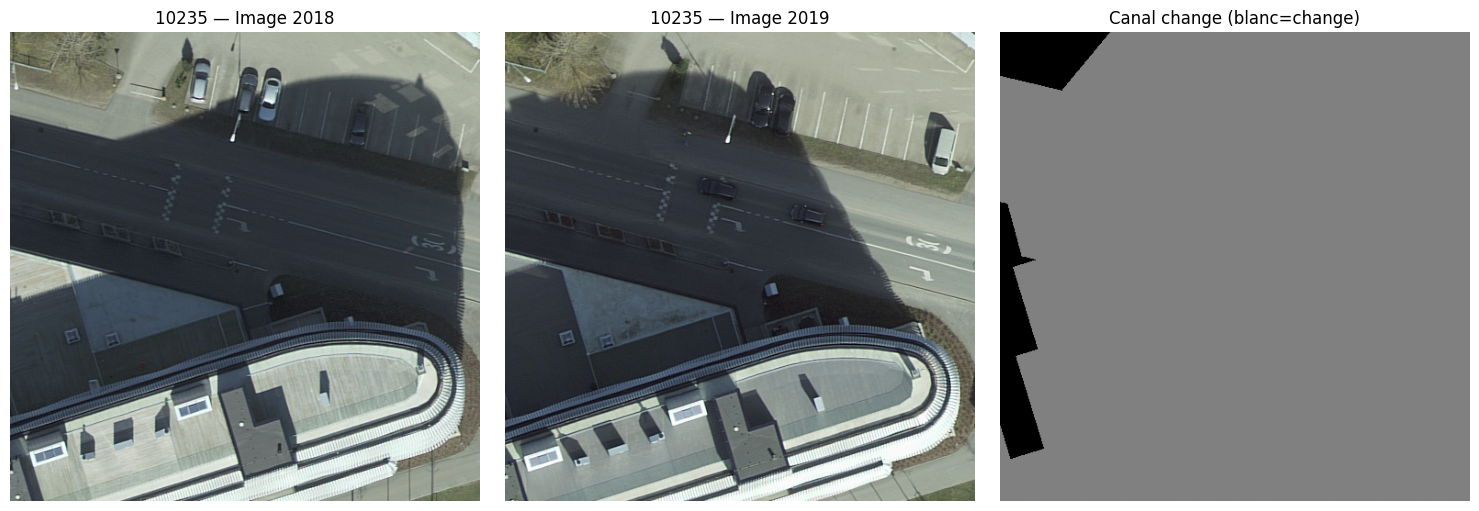

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(Image.open(ROOT / "train" / "image" / "2018" / f"{nom}.png"))
ax[0].set_title(f"{nom} — Image 2018")
ax[1].imshow(Image.open(ROOT / "train" / "image" / "2019" / f"{nom}.png"))
ax[1].set_title(f"{nom} — Image 2019")
ax[2].imshow(m[:, :, 2], cmap="gray", vmin=0, vmax=2)
ax[2].set_title("Canal change (blanc=change)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

# 02 - Mise en place des scripts et test

In [13]:
import sys
sys.path.append('..')
from src.data.hiucd_dataset import HiUCDDataset

ROOT = "/Volumes/SSD_VICO/hi-ucd-complete"

ds = HiUCDDataset(ROOT, split="train", debug_n=5)
print("Images loaded:", len(ds))

sample = ds[0]
print("Keys:", sorted(sample.keys()))
print("image_2018 shape:", tuple(sample["image_2018"].shape))
print("change values:", sample["change"].unique().tolist())
print("valid %:", round(sample["valid"].float().mean().item() * 100, 1))

[debug] loading only 5 images
Images loaded: 5
Keys: ['change', 'image_2018', 'image_2019', 'name', 'sem_2018', 'sem_2019', 'valid']
image_2018 shape: (3, 512, 512)
change values: [0]
valid %: 100.0


In [14]:
import sys
sys.path.append('..')
import torch
from src.models.encoders.resnet_encoder import ResNetEncoder
from src.models.fusion import ConcatDiffFusion

encoder = ResNetEncoder()
fusion = ConcatDiffFusion(in_channels=encoder.out_channels)

fake_2018 = torch.randn(2, 3, 512, 512)
fake_2019 = torch.randn(2, 3, 512, 512)

feat_2018, feat_2019 = encoder(fake_2018, fake_2019)
fused = fusion(feat_2018, feat_2019)

print("Features 2018:", tuple(feat_2018.shape))
print("Fused map:", tuple(fused.shape))
print("Channels after fusion:", fusion.out_channels)

Features 2018: (2, 2048, 16, 16)
Fused map: (2, 6144, 16, 16)
Channels after fusion: 6144


In [15]:
import sys
sys.path.append('..')
import torch
from src.models.encoders.resnet_encoder import ResNetEncoder
from src.models.fusion import ConcatDiffFusion
from src.models.decoder import MultiTaskDecoder

encoder = ResNetEncoder()
fusion = ConcatDiffFusion(in_channels=encoder.out_channels)
decoder = MultiTaskDecoder(in_channels=fusion.out_channels, num_classes=10)

fake_2018 = torch.randn(2, 3, 512, 512)
fake_2019 = torch.randn(2, 3, 512, 512)

# Full chain: encode -> fuse -> decode
feat_2018, feat_2019 = encoder(fake_2018, fake_2019)
fused = fusion(feat_2018, feat_2019)
out_sem_2018, out_sem_2019, out_change = decoder(fused)

print("Semantic 2018 output:", tuple(out_sem_2018.shape))
print("Semantic 2019 output:", tuple(out_sem_2019.shape))
print("Change output:", tuple(out_change.shape))

Semantic 2018 output: (2, 10, 512, 512)
Semantic 2019 output: (2, 10, 512, 512)
Change output: (2, 1, 512, 512)


In [16]:
import sys
sys.path.append('..')
import torch
from src.models.model import ChangeDetectionModel

model = ChangeDetectionModel(num_classes=10)

fake_2018 = torch.randn(2, 3, 512, 512)
fake_2019 = torch.randn(2, 3, 512, 512)

out_sem_2018, out_sem_2019, out_change = model(fake_2018, fake_2019)

print("Semantic 2018:", tuple(out_sem_2018.shape))
print("Semantic 2019:", tuple(out_sem_2019.shape))
print("Change:", tuple(out_change.shape))

# Count trainable vs total parameters (backbone is frozen).
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", f"{total:,}")
print("Trainable parameters:", f"{trainable:,}")

Semantic 2018: (2, 10, 512, 512)
Semantic 2019: (2, 10, 512, 512)
Change: (2, 1, 512, 512)
Total parameters: 53,387,989
Trainable parameters: 29,879,957


In [17]:
import sys
sys.path.append('..')
import torch
from src.losses.losses import cross_entropy, dice_loss

# Fake model output and target, batch of 2, 10 classes, 64x64 (small for speed)
fake_logits = torch.randn(2, 10, 64, 64)
fake_target = torch.randint(0, 10, (2, 64, 64))   # labels 0..9

ce = cross_entropy(fake_logits, fake_target)
dice = dice_loss(fake_logits, fake_target)

print("CrossEntropy loss:", round(ce.item(), 4))
print("Dice loss:", round(dice.item(), 4))

CrossEntropy loss: 2.7407
Dice loss: 0.901


In [18]:
import sys
sys.path.append('..')
import torch
from src.losses.losses import focal_loss

# Fake change output, target, and validity mask
fake_change_logits = torch.randn(2, 1, 64, 64)
fake_change_target = torch.randint(0, 2, (2, 64, 64))      # 0 or 1
fake_valid = torch.rand(2, 64, 64) > 0.1                    # ~90% valid

fl = focal_loss(fake_change_logits, fake_change_target, fake_valid)
print("Focal loss:", round(fl.item(), 4))

# Quick check: a batch with NO valid pixels should return 0, not crash
no_valid = torch.zeros(2, 64, 64, dtype=torch.bool)
fl_empty = focal_loss(fake_change_logits, fake_change_target, no_valid)
print("Focal loss (no valid pixels):", round(fl_empty.item(), 4))

Focal loss: 0.1756
Focal loss (no valid pixels): 0.0


In [ ]:
import sys
sys.path.append('..')
import torch
from src.losses.losses import compute_total_loss

# Fake model outputs (batch of 2, 64x64 for speed)
fake_outputs = (
    torch.randn(2, 10, 64, 64),   # out_sem_2018
    torch.randn(2, 10, 64, 64),   # out_sem_2019
    torch.randn(2, 1, 64, 64),    # out_change
)

# Fake batch matching the dataloader's keys
fake_batch = {
    "sem_2018": torch.randint(0, 10, (2, 64, 64)),
    "sem_2019": torch.randint(0, 10, (2, 64, 64)),
    "change": torch.randint(0, 2, (2, 64, 64)),
    "valid": torch.rand(2, 64, 64) > 0.1,
}

total, parts = compute_total_loss(fake_outputs, fake_batch)

print("Total loss:", round(total.item(), 4))
print("Breakdown:")
for name, value in parts.items():
    print(f"  {name}: {round(value, 4)}")

Total loss: 7.4472
Breakdown:
  ce_2018: 2.7442
  dice_2018: 0.901
  ce_2019: 2.7314
  dice_2019: 0.9009
  focal_change: 0.1697
  total: 7.4472


In [20]:
import sys
sys.path.append('..')
from src.train import train

ROOT = "/Volumes/SSD_VICO/hi-ucd-complete"

# Smoke test: 20 images, 3 epochs, no saving. Just check the loss goes down.
model = train(ROOT, epochs=3, batch_size=4, debug_n=20, save_path=None)

[device] MPS actif -> GPU Apple Silicon (local)
[debug] loading only 20 images
epoch 1/3 | avg total loss 6.3914 | last batch: seg2018 CE 1.912 Dice 0.924 | change Focal 0.0365
epoch 2/3 | avg total loss 5.8579 | last batch: seg2018 CE 1.982 Dice 0.918 | change Focal 0.0129
epoch 3/3 | avg total loss 5.3070 | last batch: seg2018 CE 1.593 Dice 0.906 | change Focal 0.0118


In [21]:
import sys
sys.path.append('..')
import torch
from src.metrics import BinaryChangeIoU

metric = BinaryChangeIoU()

# Cas construit à la main pour vérifier le calcul.
# pred et target sur une petite grille, tous valides.
pred =   torch.tensor([[1, 1, 0, 0]])   # le modèle prédit changement sur 2 pixels
target = torch.tensor([[1, 0, 1, 0]])   # vérité : changement sur 2 autres pixels
valid =  torch.tensor([[True, True, True, True]])

metric.add(pred, target, valid)
score = metric.compute()

# À la main : intersection = 1 pixel (position 0, les deux à 1)
#             union = 3 pixels (positions 0,1,2 où au moins un vaut 1)
#             IoU = 1/3 = 0.333
print("BCD IoU:", round(score, 4), "(attendu 0.3333)")

# Vérifions aussi l'exclusion des pixels invalides
metric.reset()
valid2 = torch.tensor([[True, True, True, False]])   # dernier pixel ignoré
metric.add(pred, target, valid2)
print("BCD IoU (1 pixel exclu):", round(metric.compute(), 4), "(toujours 0.3333 ici)")

BCD IoU: 0.3333 (attendu 0.3333)
BCD IoU (1 pixel exclu): 0.3333 (toujours 0.3333 ici)


In [22]:
import sys
sys.path.append('..')
import torch
from src.metrics import SemanticMIoU

metric = SemanticMIoU(num_classes=10, ignore_index=0)

# Cas simple : 3 classes en jeu (1, 2, 3), unlabeled (0) présent mais ignoré.
# pred et target sur une petite grille.
pred =   torch.tensor([[1, 1, 2, 3]])
target = torch.tensor([[1, 2, 2, 3]])

metric.add(pred, target)

per_class = metric.compute_per_class()
print("IoU classe 1:", per_class[1])   # prédit 2 fois classe 1, vrai 1 fois -> inter 1, union 2 -> 0.5
print("IoU classe 2:", per_class[2])   # prédit 1 fois, vrai 2 fois -> inter 1, union 2 -> 0.5
print("IoU classe 3:", per_class[3])   # prédit 1, vrai 1, parfait -> 1.0
print("mIoU:", round(metric.compute(), 4))   # moyenne de 0.5, 0.5, 1.0 = 0.6667

IoU classe 1: 0.5
IoU classe 2: 0.5
IoU classe 3: 1.0
mIoU: 0.6667


In [25]:
import sys
sys.path.append('..')
from src.train import train

ROOT = "/Volumes/SSD_VICO/hi-ucd-complete"

model, history = train(ROOT, epochs=3, batch_size=4, debug_n=20,
                       save_path=None, val_debug_n=40)

# Check the history is filled
print("History keys:", list(history.keys()))
print("Loss per epoch:", [round(x, 3) for x in history["loss_total"]])
print("val mIoU per epoch:", [round(x, 4) for x in history["val_miou"]])

[device] MPS actif -> GPU Apple Silicon (local)
[debug] loading only 20 images
[debug] loading only 40 images
epoch 1/3 | loss 6.3455 (CE 4.414 Dice 1.887 Focal 0.0437) | val mIoU 0.0056 | val BCD IoU 0.0000
epoch 2/3 | loss 5.3896 (CE 3.519 Dice 1.834 Focal 0.0367) | val mIoU 0.0043 | val BCD IoU 0.0000
epoch 3/3 | loss 5.1741 (CE 3.322 Dice 1.829 Focal 0.0234) | val mIoU 0.0041 | val BCD IoU 0.0000
History keys: ['loss_total', 'loss_ce', 'loss_dice', 'loss_focal', 'val_miou', 'val_bcd']
Loss per epoch: [6.346, 5.39, 5.174]
val mIoU per epoch: [0.0056, 0.0043, 0.0041]


[device] MPS actif -> GPU Apple Silicon (local)
[debug] loading only 20 images
[debug] loading only 20 images
[debug] loading only 40 images
epoch 1/3 | train: loss 5.7624 mIoU 0.0634 BCD 0.0000 | val: loss 7.6365 mIoU 0.0048 BCD 0.0000
epoch 2/3 | train: loss 5.5498 mIoU 0.0745 BCD 0.0000 | val: loss 7.5507 mIoU 0.0065 BCD 0.0000
epoch 3/3 | train: loss 5.4875 mIoU 0.0635 BCD 0.0000 | val: loss 7.3594 mIoU 0.0079 BCD 0.0000


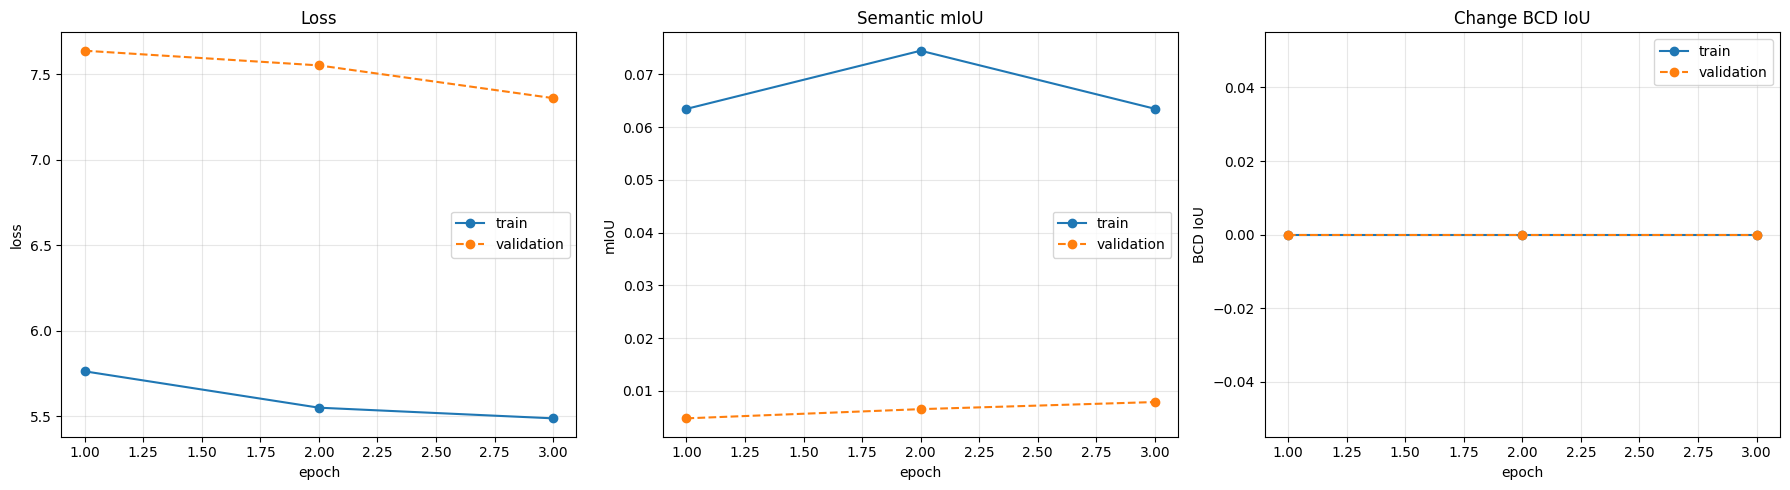

In [26]:
import sys
sys.path.append('..')
from src.train import train
from src.utils.plots import plot_history

ROOT = "/Volumes/SSD_VICO/hi-ucd-complete"

model, history = train(ROOT, epochs=3, batch_size=4, debug_n=20,
                       save_path=None, val_debug_n=40, train_eval_n=20)

plot_history(history)

[device] MPS actif -> GPU Apple Silicon (local)
[debug] loading only 200 images
[debug] loading only 200 images
[debug] loading only 200 images
epoch 1/2 | train: loss 5.0629 mIoU 0.1031 BCD 0.0000 | val: loss 7.2205 mIoU 0.0059 BCD 0.0000
epoch 2/2 | train: loss 4.0278 mIoU 0.1467 BCD 0.0000 | val: loss 13.2100 mIoU 0.0055 BCD 0.0000
Saved model to ../outputs/checkpoints/calibration.pth


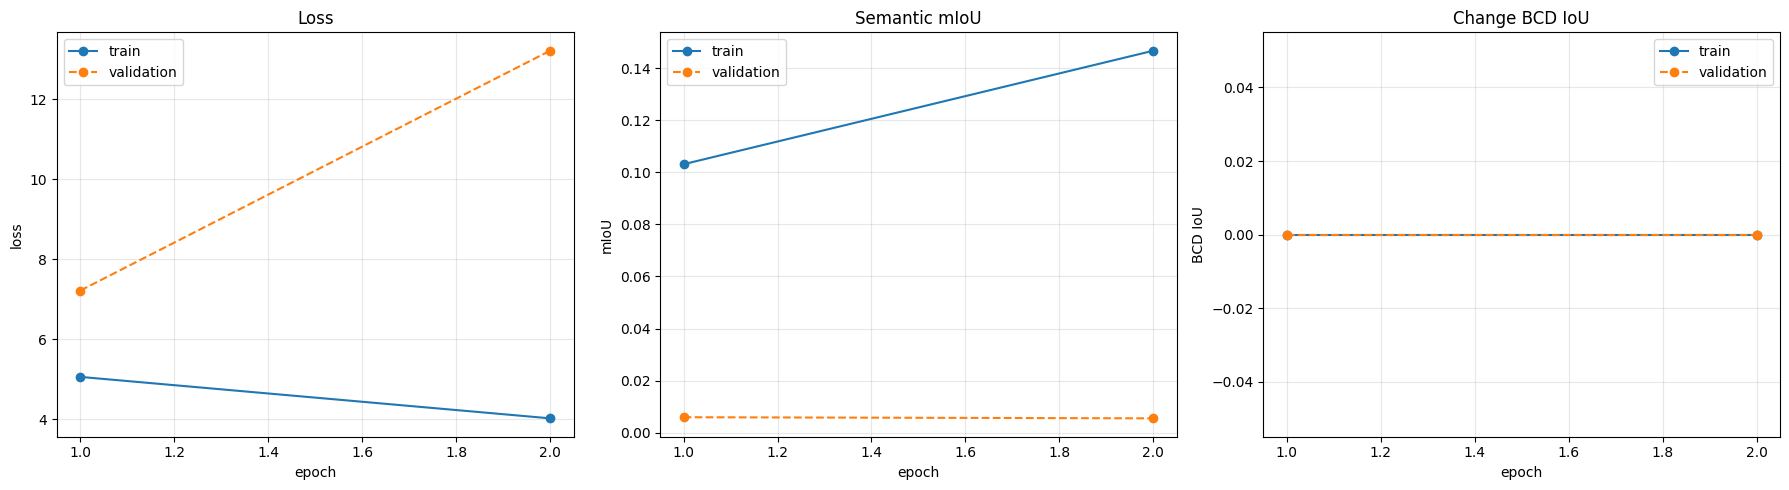

In [29]:
import sys
sys.path.append('..')
from src.train import train
from src.utils.plots import plot_history

ROOT = "/Volumes/SSD_VICO/hi-ucd-complete"

model, history = train(
    ROOT,
    epochs=2,
    batch_size=4,
    lr=1e-4,
    debug_n=200,        # 1000 train images (real signal, not a smoke test)
    val_debug_n=200,     # measure on 200 validation images
    train_eval_n=200,    # measure on 200 train images
    save_path="../outputs/checkpoints/calibration.pth",  # save the weights
)

plot_history(history)